In [1]:
import os
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt
# os.chdir("/mnt/e/project/Benchmark_velocity/revision/snRNA")
# os.getcwd()

In [2]:
data_dir = "/mnt/f/velocity_dataset_e/dataset/human_brain_sn/processed/"
fig_dir = "./figs/"
os.makedirs(fig_dir, exist_ok=True)


# 计算排名

In [3]:
from pathlib import Path

import pandas as pd
from IPython.display import display

metrics_dir = Path("/mnt/e/project/Benchmark_velocity/revision/snRNA/metrics")
metric_files = {
    "CBDir": "cbdir_df.csv",
    "ICVCoh": "icvcoh_df.csv",
}


def load_metric_long(dataset_name, metric_name):
    df = pd.read_csv(metrics_dir / dataset_name / metric_files[metric_name])
    fold_cols = [col for col in df.columns if col != "Method"]
    long_df = df.melt(
        id_vars="Method",
        value_vars=fold_cols,
        var_name="Fold",
        value_name=metric_name,
    )
    return df, long_df


def compute_direction_rank(dataset_name):
    rank_tables = []
    method_sets = {}

    for metric_name, file_name in metric_files.items():
        df = pd.read_csv(metrics_dir / dataset_name / file_name)
        fold_cols = [col for col in df.columns if col != "Method"]
        method_sets[metric_name] = set(df["Method"])

        metric_summary = pd.DataFrame({"Method": df["Method"]})
        metric_summary[f"{metric_name}_mean"] = df[fold_cols].mean(axis=1)
        metric_summary[f"{metric_name}_rank"] = metric_summary[f"{metric_name}_mean"].rank(
            ascending=False,
            method="average",
        )
        rank_tables.append(metric_summary)

    common_methods = set.intersection(*method_sets.values())
    excluded_methods = sorted(set.union(*method_sets.values()) - common_methods)
    if excluded_methods:
        print(
            f"{dataset_name}: skipped methods with inconsistent names across metrics: {excluded_methods}"
        )

    rank_df = rank_tables[0][rank_tables[0]["Method"].isin(common_methods)].copy()
    for table in rank_tables[1:]:
        table = table[table["Method"].isin(common_methods)].copy()
        rank_df = rank_df.merge(table, on="Method", how="inner")

    rank_df["Direction_rank_mean"] = rank_df[["CBDir_rank", "ICVCoh_rank"]].mean(axis=1)
    rank_df["Direction_rank"] = rank_df["Direction_rank_mean"].rank(
        ascending=True,
        method="average",
    )

    return rank_df.sort_values("Direction_rank").reset_index(drop=True)


sn_rank_df = compute_direction_rank("sn_human_brain")
sc_rank_df = compute_direction_rank("sc_human_brain")

rank_compare = sn_rank_df[["Method", "Direction_rank"]].rename(
    columns={"Direction_rank": "sn_human_brain"}
).merge(
    sc_rank_df[["Method", "Direction_rank"]].rename(
        columns={"Direction_rank": "sc_human_brain"}
    ),
    on="Method",
    how="inner",
)

display(sn_rank_df)
display(sc_rank_df)
display(rank_compare.sort_values(["sn_human_brain", "sc_human_brain"]).reset_index(drop=True))


sc_human_brain: skipped methods with inconsistent names across metrics: ['velovae_full', 'velovae_fullvb']


,Method,CBDir_mean,CBDir_rank,ICVCoh_mean,ICVCoh_rank,Direction_rank_mean,Direction_rank
0,pyrovelocity_m1,0.249479,2.0,0.881837,5.0,3.5,1.0
1,unitvelo_uni,0.102743,10.0,0.936787,1.0,5.5,2.0
2,celldancer,0.107537,9.0,0.910063,3.0,6.0,3.0
3,veloae,0.196930,3.0,0.822249,12.0,7.5,4.5
4,velovi,0.174044,6.0,0.847782,9.0,7.5,4.5
5,scvelo_dyn,0.188658,4.0,0.813793,13.0,8.5,6.0
6,unitvelo_ind,0.124318,8.0,0.845963,10.0,9.0,8.0
7,latentvelo_std,0.074567,12.0,0.875883,6.0,9.0,8.0
8,sctour_mse,0.271761,1.0,0.780263,17.0,9.0,8.0
9,sctour_nb,0.044298,15.0,0.889158,4.0,9.5,10.5


,Method,CBDir_mean,CBDir_rank,ICVCoh_mean,ICVCoh_rank,Direction_rank_mean,Direction_rank
0,scvelo_stc,0.309864,2.0,0.713065,8.0,5.0,1.0
1,unitvelo_ind,0.254221,4.0,0.689284,11.0,7.5,2.0
2,velovi,0.179286,10.0,0.760870,7.0,8.5,3.0
3,pyrovelocity_m2,0.024090,15.0,0.819587,3.0,9.0,4.0
4,velocyto,0.273421,3.0,0.630874,16.0,9.5,5.5
5,pyrovelocity_m1,0.223296,7.0,0.678800,12.0,9.5,5.5
6,deepvelo,0.216513,8.0,0.654034,13.0,10.5,7.5
7,latentvelo_std,-0.023975,19.0,0.854864,2.0,10.5,7.5
8,unitvelo_uni,-0.089944,21.0,0.873312,1.0,11.0,9.0
9,sctour_nb,-0.008269,18.0,0.771601,5.0,11.5,10.0


,Method,sn_human_brain,sc_human_brain
0,pyrovelocity_m1,1.0,5.5
1,unitvelo_uni,2.0,9.0
2,celldancer,3.0,17.5
3,velovi,4.5,3.0
4,veloae,4.5,17.5
5,scvelo_dyn,6.0,13.0
6,unitvelo_ind,8.0,2.0
7,latentvelo_std,8.0,7.5
8,sctour_mse,8.0,17.5
9,sctour_nb,10.5,10.0


In [4]:
method_rename_dict = {
        'velocyto': "Velocyto",
        'scvelo_dyn': "scVelo (dyn)",
        'scvelo_stc': "scVelo (stc)",
        'veloae': "VeloAE",
        'dynamo_m1': "Dynamo (m1)",
        'unitvelo_ind': "UniTVelo (ind)",
        'unitvelo_uni': "UniTVelo (uni)",
        'velovae_std': "VeloVAE (std)",
        'velovae_fullvb': "VeloVAE (Full VB)",
        'deepvelo': "DeepVelo",
        'celldancer': "cellDancer",
        'pyrovelocity_m1': "Pyro-Velocity (m1)",
        'pyrovelocity_m2': "Pyro-Velocity (m2)",
        'kvelo': "κ-velo",
        'velovi': "veloVI",
        'cell2fate': "cell2fate",
        'sdevelo': "SDEvelo",
        'svelvetvae': "SvelvetVAE",
        'latentvelo_std': "LatentVelo (std)",
        'tivelo_std': "TIVelo (std)",
        'tivelo_simple': "TIVelo (simple)",
        'multivelo': "MultiVelo",
        'velvetvae': "VelvetVAE",
        'graphvelo_std': "GraphVelo (std)",
        'sctour_mse': "scTour (MSE)",
        'sctour_nb': "scTour (NB)",
        'sctour_zinb': "scTour (ZINB)"}

In [5]:
method_colors = {
    'velocyto': "#6587AB",
    'scvelo_dyn': "#76B7B2",
    'scvelo_stc': "#92CB8A",
    'veloae': "#F6A24F",
    'dynamo_m1': "#DC6F71",
    'pyrovelocity_m1': "#006e54",
    'pyrovelocity_m2': "#a7e6d7",
    'unitvelo_uni': "#aa4c8f",
    'unitvelo_ind': "#E9B6DA",
    'velovae_std': "#C6A11B",
    'velovae_fullvb': "#FBEBB2",
    'kvelo': "#FAAEA0",
    'celldancer': "#7ABBEF",
    'velovi': "#A4AB47",
    'latentvelo_std': "#C4D6A0",
    'sctour_mse': "#4d5aaf",
    'sctour_nb': "#8491c3",
    'sctour_zinb': "#bbc8e6",
    'deepvelo': "#D2660D",
    'sdevelo': "#22808B",
    'svelvetvae': "#F6D55C",
    'cell2fate': "#AD2513",
    'tivelo_std': "#333631",
    'tivelo_simple': "#AFB39F",
    'graphvelo_std': "#8D6262"
}

Spearman rho (sn_human_brain vs sc_human_brain): 0.1583
Spearman p-value: 0.46


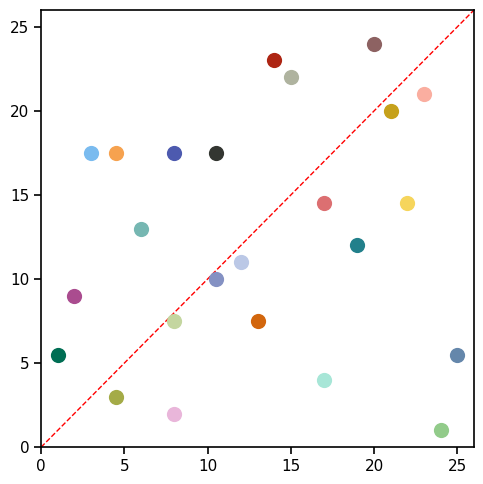

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="white")


def style_axis(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.2)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=5,
        width=1.2,
        colors="black",
        bottom=True,
        top=False,
        left=True,
        right=False,
    )


spearman_rho, spearman_p = spearmanr(rank_compare["sn_human_brain"], rank_compare["sc_human_brain"])
print(f"Spearman rho (sn_human_brain vs sc_human_brain): {spearman_rho:.4f}")
print(f"Spearman p-value: {spearman_p:.4g}")

fig, ax = plt.subplots(figsize=(5, 5))

for row in rank_compare.sort_values(["sn_human_brain", "sc_human_brain"]).itertuples(index=False):
    method_color = method_colors.get(row.Method, "#4c4c4c")
    ax.scatter(
        row.sn_human_brain,
        row.sc_human_brain,
        s=120,
        color=method_color,
        linewidth=0,
        zorder=3,
    )

lims = [
    rank_compare[["sn_human_brain", "sc_human_brain"]].to_numpy().min(),
    rank_compare[["sn_human_brain", "sc_human_brain"]].to_numpy().max(),
]

x_ticks = np.arange(np.floor(lims[0]) - 1, np.ceil(lims[1]) + 1, 5)
y_ticks = np.arange(np.floor(lims[0]) - 1, np.ceil(lims[1]) + 1, 5)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xlim(lims[0] - 1, lims[1] + 1)
ax.set_ylim(lims[0] - 1, lims[1] + 1)

ax.set_xlabel("")
ax.set_ylabel("")

tick_start = np.floor(lims[0]) - 1
tick_end = np.ceil(lims[1]) + 1

ax.plot(
    [tick_start, tick_end],
    [tick_start, tick_end],
    linestyle="--",
    color="red",
    linewidth=1,
    zorder=1,
)

style_axis(ax)
plt.tight_layout()
plt.savefig(f"{fig_dir}sn_vs_sc_rank.svg", format="svg", bbox_inches="tight", dpi=150)
plt.show()

In [7]:
from scipy.sparse import issparse
from sklearn.linear_model import LinearRegression

In [8]:
adata_1_1 = sc.read("../Fig3/data07/adata_run_velocyto_full_new.h5ad")
adata_1_2 = sc.read("../Fig3/data08/adata_run_velocyto_full_new.h5ad")
adata_2_1 = sc.read("../Fig3/data07/adata_run_scvelo_stc_full_new.h5ad")
adata_2_2 = sc.read("../Fig3/data08/adata_run_scvelo_stc_full_new.h5ad")

data07_color_map = {
    "Cyc. Prog.": "#f19072",
    "Early RG": "#507ea4",
    "Late RG": "#19448e",
    "nIPC": "#fbd26b",
    "GluN": "#c3eadc",
}

data08_color_map = {
    "Mature \n Excitatory Neuron": "#fad4b5",
    "Immature \n Excitatory Neuron": "#eea073",
    "Newborn \n Excitatory Neuron": "#cf6d31",
    "Intermediate \n Progenitor": "#6c2c2f",
    "Radial Glia": "#583822",
}

dataset_configs = [
    {
        "name": "data07",
        "methods": {
            "velocyto": adata_1_1,
            "scvelo_stc": adata_2_1,
        },
        "color_map": data07_color_map,
    },
    {
        "name": "data08",
        "methods": {
            "velocyto": adata_1_2,
            "scvelo_stc": adata_2_2,
        },
        "color_map": data08_color_map,
    },
]
genes_to_plot = ["MLLT3", "NFIA", "ROBO2"]



In [9]:
def to_dense_1d(x):
    if issparse(x):
        x = x.toarray()
    return np.asarray(x).ravel()

def choose_su_layers(adata):
    """
    Prefer smoothed layers Ms/Mu if available.
    Otherwise use raw spliced/unspliced.
    """
    if "Ms" in adata.layers and "Mu" in adata.layers:
        return "Ms", "Mu"
    elif "spliced" in adata.layers and "unspliced" in adata.layers:
        return "spliced", "unspliced"
    else:
        raise ValueError(
            "Cannot find Ms/Mu or spliced/unspliced in adata.layers."
        )
    
def fit_no_intercept_line(s, u):
    """
    Fit u = gamma * s.
    This is closer to a steady-state slope through origin.
    """
    if len(s) < 10 or np.std(s) == 0:
        return np.nan

    model = LinearRegression(fit_intercept=False)
    model.fit(s.reshape(-1, 1), u)
    return float(model.coef_[0])

In [10]:
def get_su_with_mask(adata, gene, s_layer=None, u_layer=None):
    if s_layer is None or u_layer is None:
        s_layer, u_layer = choose_su_layers(adata)

    gidx = adata.var_names.get_loc(gene)
    s = to_dense_1d(adata.layers[s_layer][:, gidx])
    u = to_dense_1d(adata.layers[u_layer][:, gidx])
    mask = np.isfinite(s) & np.isfinite(u)
    return s[mask], u[mask], mask


def get_method_fit_ratio(adata, gene, method):
    """Read each method's stored steady-state ratio from adata.var."""
    prefixes = {
        "velocyto": ["velocyto_velocity"],
        "scvelo_stc": ["scvelo_stc_velocity", "scvelo_st_velocity"],
    }.get(method, [f"{method}_velocity"])

    suffixes = ["gamma", "qreg_ratio"]
    for prefix in prefixes:
        for suffix in suffixes:
            key = f"{prefix}_{suffix}"
            if key not in adata.var.columns:
                continue
            value = adata.var.loc[gene, key]
            if np.isfinite(value):
                return float(value), key

    s, u, _ = get_su_with_mask(adata, gene)
    return fit_no_intercept_line(s, u), "fit_no_intercept"


def robust_axis_limit(values, quantile=99.5, pad=1.08):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return 1

    upper = np.nanpercentile(values, quantile)
    if not np.isfinite(upper) or upper <= 0:
        upper = np.nanmax(values)
    if not np.isfinite(upper) or upper <= 0:
        upper = 1
    return upper * pad


def plot_phase_dataset_pair(
    dataset_configs,
    gene,
    color_key="clusters",
    base_method="velocyto",
    point_size=6,
    alpha=0.55,
    same_axis_per_gene=False,
    axis_quantile=99.5,
):
    from matplotlib.ticker import MultipleLocator, MaxNLocator, StrMethodFormatter

    method_labels = {
        "velocyto": "velocyto ratio",
        "scvelo_stc": "scvelo_stc ratio",
    }
    line_colors = {
        "velocyto": "#6587AB",
        "scvelo_stc": "#92CB8A",
    }

    panels = []
    global_s = []
    global_u = []

    for cfg in dataset_configs:
        base_adata = cfg["methods"][base_method]
        s_base, u_base, base_mask = get_su_with_mask(base_adata, gene)

        method_fits = {}
        for method, adata in cfg["methods"].items():
            ratio, ratio_key = get_method_fit_ratio(adata, gene, method)
            method_fits[method] = {"ratio": ratio, "key": ratio_key}

        panel_x_lim = robust_axis_limit(s_base, quantile=axis_quantile)
        panel_y_lim = robust_axis_limit(u_base, quantile=axis_quantile)
        global_s.append(s_base)
        global_u.append(u_base)

        panels.append({
            "config": cfg,
            "base_adata": base_adata,
            "s": s_base,
            "u": u_base,
            "mask": base_mask,
            "method_fits": method_fits,
            "x_lim": panel_x_lim,
            "y_lim": panel_y_lim,
        })

    if panels:
        data07_y_lim = panels[0]["y_lim"]
        for panel in panels:
            panel["x_lim"] = 4
            panel["y_lim"] = data07_y_lim

    if same_axis_per_gene:
        x_lim = robust_axis_limit(np.concatenate(global_s), quantile=axis_quantile)
        y_lim = robust_axis_limit(np.concatenate(global_u), quantile=axis_quantile)
        for panel in panels:
            panel["x_lim"] = x_lim
            panel["y_lim"] = y_lim

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(5.5, 2.7),
        gridspec_kw={"wspace": 0.16},
    )

    for ax, panel in zip(axes, panels):
        cfg = panel["config"]
        adata = panel["base_adata"]
        s = panel["s"]
        u = panel["u"]
        mask = panel["mask"]
        x_lim = panel["x_lim"]
        y_lim = panel["y_lim"]
        color_map = cfg["color_map"].copy()

        if color_key is not None and color_key in adata.obs.columns:
            cats = adata.obs[color_key].astype("category")
            all_types = cats.cat.categories
            for ct in all_types:
                if ct not in color_map:
                    color_map[ct] = "#a8a8ab"

            cats_masked = cats[mask]
            for cat in all_types:
                idx = (cats_masked == cat).to_numpy()
                if np.any(idx):
                    ax.scatter(
                        s[idx],
                        u[idx],
                        s=point_size,
                        alpha=alpha,
                        color=color_map[cat],
                        linewidths=0,
                        rasterized=True,
                    )
        else:
            ax.scatter(
                s,
                u,
                s=point_size,
                alpha=alpha,
                color="#a8a8ab",
                linewidths=0,
                rasterized=True,
            )

        ax.set_xlim(0, 4)
        ax.set_ylim(0, y_lim)
        x_line = np.linspace(0, x_lim, 100)

        for method, fit_info in panel["method_fits"].items():
            ratio = fit_info["ratio"]
            if not np.isfinite(ratio):
                continue
            ax.plot(
                x_line,
                ratio * x_line,
                color=line_colors.get(method, "#333333"),
                linestyle="--",
                linewidth=1.25,
                label=f"{method_labels.get(method, method)} ({ratio:.2f})",
                clip_on=True,
            )

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")
        ax.set_box_aspect(1)
        ax.set_xticks([0, 1, 2, 3, 4])
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
        ax.yaxis.set_major_locator(MaxNLocator(4))
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_linewidth(1.0)
        ax.spines["bottom"].set_linewidth(1.0)
        ax.spines["top"].set_visible("black")
        ax.spines["right"].set_visible("black")
        ax.tick_params(
            axis="both",
            which="major",
            direction="out",
            length=4,
            width=1.0,
            color="black",
            labelcolor="black",
            bottom=True,
            left=True,
            top=False,
            right=False,
            labelbottom=True,
            labelleft=True,
        )
        # ax.legend(frameon=False, fontsize=7, handlelength=1.8, loc="upper right")

    fig.subplots_adjust(left=0.10, right=0.99, bottom=0.18, top=0.98, wspace=0.16)
    return fig, axes


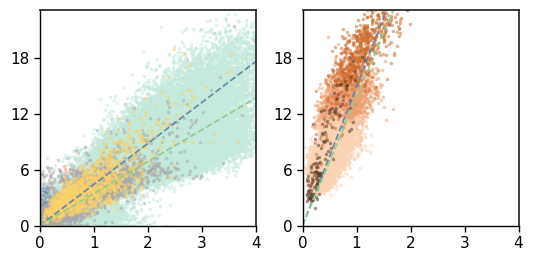

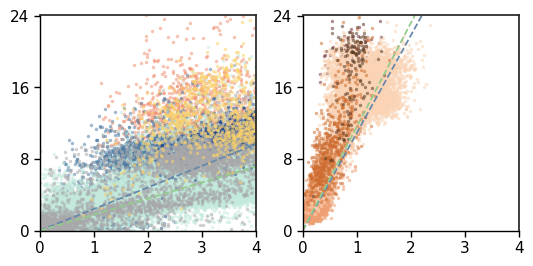

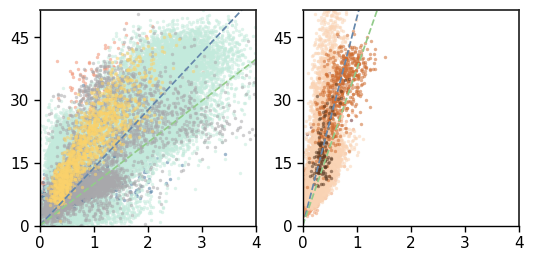

In [11]:
from pathlib import Path

save_dir = Path("./us_ratio_plots")
save_dir.mkdir(parents=True, exist_ok=True)

for gene in genes_to_plot:
    fig, axes = plot_phase_dataset_pair(
        dataset_configs,
        gene,
        color_key="clusters",
        base_method="velocyto",
        same_axis_per_gene=False,
        axis_quantile=99.9,
    )
    fig.savefig(save_dir / f"{gene}_us_ratio.png", bbox_inches="tight", dpi=150)
    plt.show()


# sctour的stream plot

In [12]:
from scipy.sparse import issparse

In [13]:
umap_colors = [
    "#fad4b5",
    "#eea073",
    "#cf6d31",
    "#6c2c2f",
    "#583822"
]

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:04) --> added 
    'sctour_mse_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'sctour_mse_velocity_umap', embedded velocity vectors (adata.obsm)


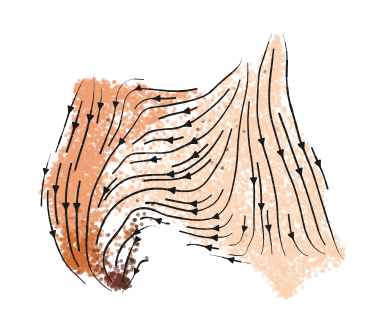

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'sctour_nb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'sctour_nb_velocity_umap', embedded velocity vectors (adata.obsm)


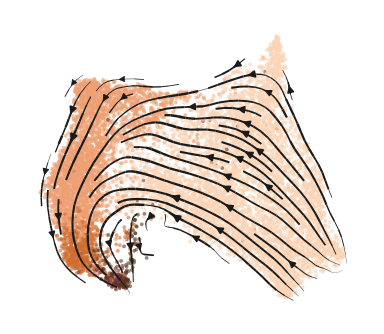

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'sctour_zinb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'sctour_zinb_velocity_umap', embedded velocity vectors (adata.obsm)


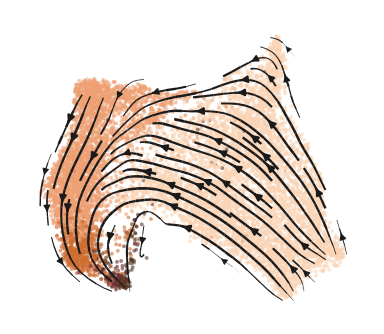

In [14]:
cluster_key = 'clusters'
dataset = 'human_brain_sn'

data_dir = "/mnt/f/velocity_dataset_e/dataset/"

color_map = {
    'Mature \n Excitatory Neuron': "#fad4b5",
    'Immature \n Excitatory Neuron': "#eea073",
    'Newborn \n Excitatory Neuron': "#cf6d31",
    'Intermediate \n Progenitor': "#6c2c2f",
    'Radial Glia': "#583822",
}

for method in ['sctour_mse', 'sctour_nb', 'sctour_zinb']:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method}_full.h5ad")
    adata.layers[vkey] = adata.layers[vkey].astype(np.float32)
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])

    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform, n_jobs=20)

    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories

    # 按 category 顺序生成颜色列表
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]

    kwargs = dict(
        frameon=True, add_margin=.1, density=1, linewidth=1,
        size=30, alpha=0.6,
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{fig_dir}{dataset}_{method}_stream.png", bbox_inches='tight', dpi=150)
    plt.show()

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'sctour_mse_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'sctour_mse_velocity_umap', embedded velocity vectors (adata.obsm)


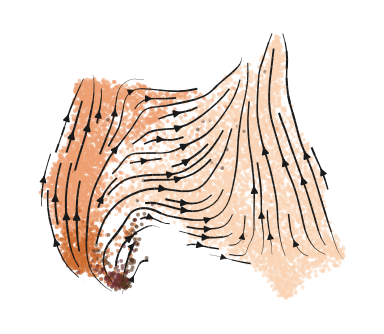

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'sctour_nb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'sctour_nb_velocity_umap', embedded velocity vectors (adata.obsm)


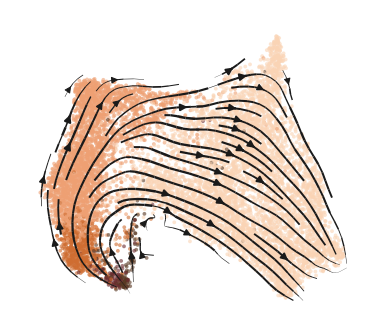

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'sctour_zinb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:02) --> added
    'sctour_zinb_velocity_umap', embedded velocity vectors (adata.obsm)


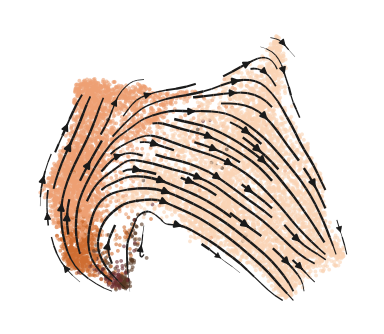

In [15]:
cluster_key = 'clusters'
dataset = 'human_brain_sn'

data_dir = "/mnt/f/velocity_dataset_e/dataset/"

color_map = {
    'Mature \n Excitatory Neuron': "#fad4b5",
    'Immature \n Excitatory Neuron': "#eea073",
    'Newborn \n Excitatory Neuron': "#cf6d31",
    'Intermediate \n Progenitor': "#6c2c2f",
    'Radial Glia': "#583822",
}

for method in ['sctour_mse', 'sctour_nb', 'sctour_zinb']:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method}_full.h5ad")
    adata.layers[vkey] = -adata.layers[vkey].astype(np.float32)
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])

    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform, n_jobs=20)

    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories

    # 按 category 顺序生成颜色列表
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]

    kwargs = dict(
        frameon=True, add_margin=.1, density=1, linewidth=1,
        size=30, alpha=0.6,
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{fig_dir}{dataset}_{method}_stream_reverse.png", bbox_inches='tight', dpi=150)
    plt.show()